# Tarea 2 -- Modelo de propension: pension_plan

easyMoney - TFM Nuclio Digital School

Este notebook entrena y evalua un modelo de propension a la compra de `pension_plan`, el producto con mayor margen (79% del margen total, segun la Tarea 1). Parte del panel guardado por `02_preprocessing_propension.ipynb`.

Resumen del enfoque:
- Target: adquisicion nueva (el cliente no tenia el producto el mes anterior y lo tiene este mes).
- Features: lag-1 de variables demograficas y de actividad (nunca datos del mes actual, para evitar leakage).
- Split temporal estricto: train / test (penultimo mes) / validacion (ultimo mes).
- Modelo: Random Forest (ensemble de arboles) con `class_weight='balanced'` (el target esta muy desbalanceado). Sustituimos un unico arbol por un ensemble porque un arbol de profundidad limitada solo puede devolver un puñado de probabilidades distintas (una por hoja), lo que dejaba a muchos clientes empatados exactamente en la misma probabilidad -- ver seccion 5.
- Evaluacion: metricas tecnicas (classification_report, matriz de confusion, ROC/AUC con `predict_proba`) + una metrica de negocio (conversion real si se contacta al top 5% de clientes por probabilidad).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

df_panel = pd.read_parquet('../data/processed/df_panel_propension.parquet', engine='pyarrow')
print(df_panel.shape)

(5961849, 39)


## 1. Target: adquisicion nueva de pension_plan

`diff()` calcula, PARA CADA CLIENTE POR SEPARADO (gracias al `groupby`), la diferencia entre el valor de `pension_plan` de este mes y el del mes anterior:
- `0 -> 1` => `diff = 1` (adquisicion nueva: esto es lo que queremos detectar)
- `1 -> 1` => `diff = 0` (ya lo tenia, no es 'nuevo')
- `0 -> 0` => `diff = 0` (sigue sin tenerlo)
- primer mes de cada cliente => `diff = NaN` (no hay mes anterior, se descarta mas adelante)

In [2]:
df_panel['target'] = df_panel.groupby('pk_cid')['pension_plan'].diff()
df_panel['target'] = df_panel['target'].apply(lambda x: 1 if x == 1 else 0)

print(df_panel['target'].value_counts())
print(f"Total de adquisiciones nuevas de pension_plan: {df_panel['target'].sum()}")

target
0    5924994
1      36855
Name: count, dtype: int64
Total de adquisiciones nuevas de pension_plan: 36855


## 2. Nuevas Features

Features que usa este modelo (todas en su version `_lag1`, es decir, el valor del mes anterior), mas `mes` (categorica, sin lag -- ver notebook de preprocessing) para capturar estacionalidad. No incluimos `em_acount_lag1` aqui porque no lo validamos como feature en este modelo -- se puede anadir mas adelante como mejora. Filtramos a clientes que el mes anterior NO tenian `pension_plan` (los unicos que pueden generar un target=1 real, y a los unicos que tendria sentido ofrecerles el producto) y quitamos el primer mes de cada cliente (sin lag disponible).

Se anaden `region_code_lag1` (provincia del mes anterior, tratada como categorica pese a ser numerica) y `antiguedad_meses_lag1` (meses como cliente, a fecha del mes anterior).

In [3]:
features_base = ['age', 'salary', 'gender', 'segment', 'entry_channel',
                  'active_customer', 'num_products', 'region_code', 'antiguedad_meses']
lag_cols_necesarias = [f'{c}_lag1' for c in features_base] + ['pension_plan_lag1']

df_model = df_panel.dropna(subset=lag_cols_necesarias).copy()
df_model = df_model[df_model['pension_plan_lag1'] == 0].copy()

print('Filas en el panel completo:', df_panel.shape[0])
print('Filas tras quitar primer mes y filtrar elegibles:', df_model.shape[0])
print(df_model['target'].value_counts())

Filas en el panel completo: 5961849
Filas tras quitar primer mes y filtrar elegibles: 5305179
target
0    5268324
1      36855
Name: count, dtype: int64


In [4]:
df_model.head()

,pk_cid,pk_partition,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,...,gender_lag1,segment_lag1,entry_channel_lag1,active_customer_lag1,num_products_lag1,region_code_lag1,antiguedad_meses_lag1,pension_plan_lag1,em_acount_lag1,target
1,15891,2018-08-01,0,0,0,0,0,0,0,0,...,H,02 - PARTICULARES,KAT,1.0,1.0,28.0,0.0,0.0,1.0,0
3,16063,2018-12-01,0,0,0,0,0,0,0,0,...,H,02 - PARTICULARES,KAT,1.0,0.0,28.0,0.0,0.0,0.0,0
4,16063,2019-01-01,0,0,0,0,0,0,0,0,...,H,02 - PARTICULARES,KAT,1.0,0.0,28.0,1.0,0.0,0.0,0
5,16063,2019-02-01,0,0,0,0,0,0,0,0,...,H,02 - PARTICULARES,KAT,1.0,0.0,28.0,2.0,0.0,0.0,0
6,16063,2019-03-01,0,0,0,0,0,0,0,0,...,H,02 - PARTICULARES,KAT,1.0,0.0,28.0,3.0,0.0,0.0,0


## 3. Split temporal (train / test / validacion)

Cortamos por fecha, no de forma aleatoria: como los datos son un panel temporal (mismos clientes repetidos mes a mes), un split aleatorio filtraria informacion del futuro al pasado. El ultimo mes disponible se reserva para validacion, el penultimo para test, y el resto para entrenar.

In [5]:
meses = sorted(df_model['pk_partition'].unique())
mes_val = meses[-1]
mes_test = meses[-2]
print('Mes de test:', mes_test, '| Mes de validacion:', mes_val)

train = df_model[df_model['pk_partition'] < mes_test]
test = df_model[df_model['pk_partition'] == mes_test]
val = df_model[df_model['pk_partition'] == mes_val]

print('Train:', train.shape)
print('Test: ', test.shape)
print('Val:  ', val.shape)

Mes de test: 2019-04-01 00:00:00 | Mes de validacion: 2019-05-01 00:00:00
Train: (4464025, 40)
Test:  (418993, 40)
Val:   (422161, 40)


## 4. Codificacion de variables

`entry_channel` tiene decenas de categorias raras que apenas se repiten y solo meten ruido en un modelo sencillo -- las agrupamos en 'Otros' (calculando la frecuencia SOLO con train, para no filtrar informacion de test/val). Despues aplicamos One-Hot Encoding a las variables categoricas.

In [6]:
frecuencias = train['entry_channel_lag1'].value_counts(normalize=True)
categorias_frecuentes = frecuencias[frecuencias >= 0.01].index

def agrupar_entry_channel(serie):
    return serie.where(serie.isin(categorias_frecuentes), 'Otros')

train = train.copy()
test = test.copy()
val = val.copy()
train['entry_channel_lag1'] = agrupar_entry_channel(train['entry_channel_lag1'])
test['entry_channel_lag1']  = agrupar_entry_channel(test['entry_channel_lag1'])
val['entry_channel_lag1']   = agrupar_entry_channel(val['entry_channel_lag1'])

print('Categorias de entry_channel tras agrupar:', train['entry_channel_lag1'].nunique())

# region_code_lag1 y mes van en cat_cols: son codigos/categorias, no cantidades continuas,
# aunque region_code se almacene como numero.
cat_cols = ['gender_lag1', 'segment_lag1', 'entry_channel_lag1', 'region_code_lag1', 'mes']
num_cols = ['age_lag1', 'salary_lag1', 'active_customer_lag1', 'num_products_lag1', 'antiguedad_meses_lag1']

X_train = pd.get_dummies(train[num_cols + cat_cols], columns=cat_cols)
X_test  = pd.get_dummies(test[num_cols + cat_cols], columns=cat_cols)
X_val   = pd.get_dummies(val[num_cols + cat_cols], columns=cat_cols)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

y_train = train['target']
y_test = test['target']
y_val = val['target']

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('X_val:  ', X_val.shape)

Categorias de entry_channel tras agrupar: 11
X_train: (4464025, 86)
X_test:  (418993, 86)
X_val:   (422161, 86)


## 5. Modelo

**Por que Random Forest y no un unico arbol de decision.** Un arbol unico solo puede devolver un numero limitado de probabilidades distintas (como mucho, una por cada hoja), lo cual genera muchos empates al ordenar clientes por probabilidad -- un problema serio para elegir el top 5% a contactar. Un Random Forest promedia cientos de arboles, dando un abanico mucho mas fino de probabilidades.

**Por que `max_depth=15`.** Se probaron varias profundidades (3, 5, 7, 10, 15, sin limite) evaluando siempre contra el conjunto de TEST (nunca contra validacion, para no contaminarla). El resultado fue claramente creciente hasta profundidad 15 (842 compras capturadas en el top 5% de test, frente a 722 con profundidad 5) y empeoraba de nuevo sin limite (822 compras) -- señal de sobreajuste al superar el punto optimo. `max_depth=15` es el mejor equilibrio entre capacidad del modelo y generalizacion.

**Por que `class_weight='balanced'`.** El target esta muy desbalanceado (compradores << no compradores). Sin este ajuste, el modelo tendria a predecir siempre "no compra" y aun asi acertaria en la mayoria de los casos, sin ser util para el negocio.

In [7]:
modelo = RandomForestClassifier(
    n_estimators=300, max_depth=15, class_weight='balanced',
    random_state=42, n_jobs=-1
)
modelo.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       n_jobs=-1, random_state=42)

## 6. Evaluacion tecnica (sobre el mes de test)

OJO: la curva ROC/AUC se calcula sobre TEST (abril 2019), nunca sobre validacion -- validacion se reserva intacta para la metrica de negocio final (seccion 7), evaluada una unica vez.

              precision    recall  f1-score   support

   No compra       1.00      0.78      0.88    416719
      Compra       0.02      0.84      0.04      2274

    accuracy                           0.78    418993
   macro avg       0.51      0.81      0.46    418993
weighted avg       0.99      0.78      0.87    418993



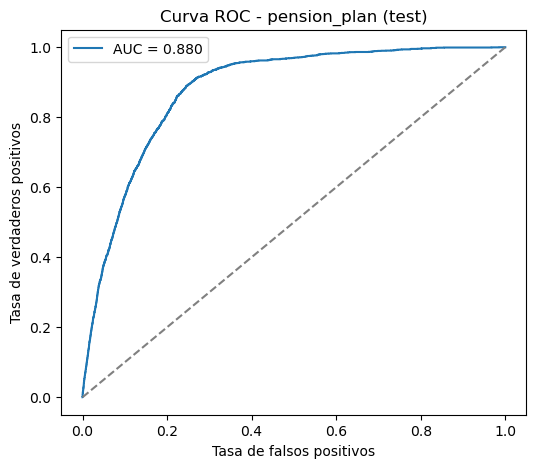

In [8]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No compra', 'Compra']))

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - pension_plan (test)')
plt.legend()
plt.show()

## 7. Evaluacion de negocio: conversion real en el top 5%

En la practica, no se contacta al 100% de los clientes elegibles -- se prioriza a los que tienen mayor probabilidad segun el modelo. Esta metrica simula justo eso: si Dan contactase solo al 5% con mayor probabilidad (segun VALIDACION, mayo 2019, nunca vista por el modelo hasta este punto), ¿que conversion real obtendria frente a contactar al azar?

In [9]:
val_proba = modelo.predict_proba(X_val)[:, 1]
print(f'Valores de probabilidad distintos en validacion: {pd.Series(val_proba).nunique()} de {len(val_proba)} clientes')

df_sim = pd.DataFrame({
    'pk_cid': val['pk_cid'].values,
    'probabilidad': val_proba,
    'compra_real': y_val.values
}).sort_values(by='probabilidad', ascending=False)

top_n = int(len(df_sim) * 0.05)
top_clientes = df_sim.head(top_n)
compras_en_top = top_clientes['compra_real'].sum()
tasa_conversion_top = compras_en_top / top_n
tasa_base = df_sim['compra_real'].mean()

print(f'Clientes en el top 5%: {top_n}')
print(f'Compras reales dentro del top: {compras_en_top}')
print(f'Tasa de conversion en el top 5%: {tasa_conversion_top*100:.2f}%')
print(f'Tasa de conversion si contactases al azar: {tasa_base*100:.2f}%')
print(f'El modelo mejora la conversion x{tasa_conversion_top/tasa_base:.1f} frente a contactar al azar')

Valores de probabilidad distintos en validacion: 306070 de 422161 clientes
Clientes en el top 5%: 21108
Compras reales dentro del top: 1075
Tasa de conversion en el top 5%: 5.09%
Tasa de conversion si contactases al azar: 0.66%
El modelo mejora la conversion x7.7 frente a contactar al azar


## Resumen de resultados (pension_plan)

- Conversion real en el top 5% (validacion, mayo 2019): **5.09%**, frente a 0.66% al azar -> **x7.7**
- El top 5% (21.108 clientes) captura **1.075** compradores reales.
- Recall clase Compra (test): **0.84** | Precision clase Compra (test): **0.02**
- Features: age, salary, gender, segment, entry_channel, active_customer, num_products, region_code, antiguedad_meses (todas `_lag1`) + mes (sin lag). Modelo: Random Forest, max_depth=15, class_weight='balanced'.

## 8. Scoring final: clientes reales a contactar hoy

Todo lo anterior evaluaba el modelo con datos historicos (sabemos si compraron o no). Aqui se aplica el modelo ya entrenado y evaluado a los clientes elegibles del ULTIMO mes disponible, para predecir el mes siguiente -- este es el resultado que se entrega a Dan.

In [10]:
# Último mes disponible: tratamos sus valores como el "mes anterior" al que
# todavía no existe en los datos (el mes que viene)
ultimo_mes = df_model['pk_partition'].max()
df_actual = df_panel[df_panel['pk_partition'] == ultimo_mes].copy()

# Solo clientes que HOY no tienen pension_plan
df_actual = df_actual[df_actual['pension_plan'] == 0].copy()

# Agrupamos entry_channel con las mismas categorías frecuentes que usamos en el modelo
df_actual['entry_channel'] = df_actual['entry_channel'].where(
    df_actual['entry_channel'].isin(categorias_frecuentes), 'Otros'
)

# El 'mes' aquí es el mes que se está PREDICIENDO (el siguiente al último disponible),
# no el mes de df_actual -- por eso se calcula aparte, sumando un mes a ultimo_mes.
mes_prediccion = (ultimo_mes + pd.DateOffset(months=1)).month
df_actual['mes'] = str(mes_prediccion).zfill(2)

# region_code y antiguedad_meses ya existen como columnas de df_panel (no hace falta
# recalcularlas); se usan tal cual, igual que age/salary, como proxy del "mes anterior".

X_actual = pd.get_dummies(
    df_actual[['age', 'salary', 'active_customer', 'num_products', 'region_code',
               'antiguedad_meses', 'gender', 'segment', 'entry_channel', 'mes']]
    .rename(columns={
        'age': 'age_lag1', 'salary': 'salary_lag1',
        'active_customer': 'active_customer_lag1', 'num_products': 'num_products_lag1',
        'region_code': 'region_code_lag1', 'antiguedad_meses': 'antiguedad_meses_lag1',
        'gender': 'gender_lag1', 'segment': 'segment_lag1', 'entry_channel': 'entry_channel_lag1'
    }),
    columns=['gender_lag1', 'segment_lag1', 'entry_channel_lag1', 'region_code_lag1', 'mes']
)
X_actual = X_actual.reindex(columns=X_train.columns, fill_value=0)

proba_actual = modelo.predict_proba(X_actual)[:, 1]
print(f'Mes que se predice: {mes_prediccion:02d}')
print(f'Valores de probabilidad distintos en el scoring final: {pd.Series(proba_actual).nunique()} de {len(proba_actual)} clientes')

df_scoring = pd.DataFrame({
    'pk_cid': df_actual['pk_cid'].values,
    'probabilidad_pension_plan': proba_actual
}).sort_values(by='probabilidad_pension_plan', ascending=False).reset_index(drop=True)

print(f'Clientes elegibles para pension_plan hoy: {len(df_scoring)}')
print(df_scoring.head(20))

df_scoring.to_csv('../data/processed/scoring_pension_plan.csv', index=False)
print('Guardado en ../data/processed/scoring_pension_plan.csv')

Mes que se predice: 06
Valores de probabilidad distintos en el scoring final: 308090 de 425556 clientes
Clientes elegibles para pension_plan hoy: 425556
     pk_cid  probabilidad_pension_plan
0   1249234                   0.907065
1   1234738                   0.902128
2   1264530                   0.901350
3   1259934                   0.901114
4   1051365                   0.900943
5   1241318                   0.900769
6   1266975                   0.900560
7   1259485                   0.900558
8   1177721                   0.900038
9   1208895                   0.899311
10  1243200                   0.899066
11  1230927                   0.898567
12  1255976                   0.898541
13  1243271                   0.898531
14  1181448                   0.898398
15  1252899                   0.898185
16  1134964                   0.897854
17  1173023                   0.897611
18  1233469                   0.897509
19  1131708                   0.897482
Guardado en ../data/processe

In [11]:
df_sim.to_csv("../data/processed/validacion_pension_plan.csv", index=False)
print("Guardado validacion_pension_plan.csv:", df_sim.shape)

Guardado validacion_pension_plan.csv: (422161, 3)
